# Modelos de Machine Learning
## Supervisionados · Não Supervisionados · Aprendizado Contínuo

Notebook com implementações práticas usando dados aleatórios e visualizações para cada modelo.

| Seção | Modelos |
|---|---|
| Supervisionado | Regressão Linear, Regressão Logística, SVM, Árvore de Decisão, Random Forest |
| Não Supervisionado | K-Means, PCA, DBSCAN |
| Aprendizado Contínuo | SGD Online Learning |

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import make_classification, make_blobs, make_regression
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3
})
print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


---
## 1. Modelos Supervisionados
Aprendem a partir de dados **rotulados** (pares entrada → saída conhecida).

### 1.1 Regressão Linear
Prediz um valor contínuo modelando a relação linear entre variáveis.

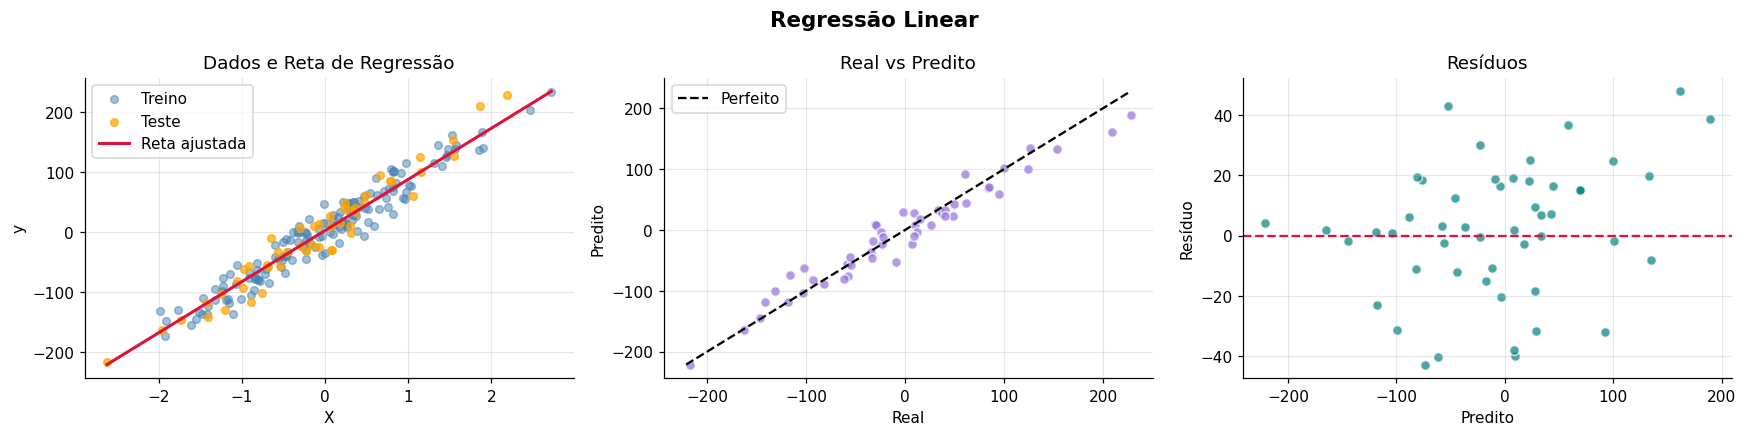

RMSE : 21.96
R²   : 0.9427
Coef : 85.2677  |  Intercepto: 2.3103


In [3]:
# --- Dados aleatórios ---
X_reg, y_reg = make_regression(n_samples=200, n_features=1, noise=20, random_state=SEED)
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.25, random_state=SEED)

# --- Modelo ---
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

# --- Gráficos ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Regressão Linear', fontsize=14, fontweight='bold')

# 1) Dispersão + linha de regressão
x_line = np.linspace(X_reg.min(), X_reg.max(), 200).reshape(-1, 1)
axes[0].scatter(X_train, y_train, alpha=0.5, label='Treino', color='steelblue', s=25)
axes[0].scatter(X_test,  y_test,  alpha=0.7, label='Teste',  color='orange',    s=25)
axes[0].plot(x_line, lr.predict(x_line), color='crimson', lw=2, label='Reta ajustada')
axes[0].set_title('Dados e Reta de Regressão')
axes[0].set_xlabel('X'); axes[0].set_ylabel('y')
axes[0].legend()

# 2) Real vs Predito
axes[1].scatter(y_test, y_pred, alpha=0.7, color='mediumpurple', edgecolors='white', s=40)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lims, lims, 'k--', lw=1.5, label='Perfeito')
axes[1].set_title('Real vs Predito')
axes[1].set_xlabel('Real'); axes[1].set_ylabel('Predito')
axes[1].legend()

# 3) Resíduos
residuos = y_test - y_pred
axes[2].scatter(y_pred, residuos, alpha=0.7, color='teal', edgecolors='white', s=40)
axes[2].axhline(0, color='crimson', lw=1.5, linestyle='--')
axes[2].set_title('Resíduos')
axes[2].set_xlabel('Predito'); axes[2].set_ylabel('Resíduo')

plt.tight_layout()
plt.show()

print(f'RMSE : {rmse:.2f}')
print(f'R²   : {r2:.4f}')
print(f'Coef : {lr.coef_[0]:.4f}  |  Intercepto: {lr.intercept_:.4f}')

### 1.2 Regressão Logística (Classificação Binária)
Classifica exemplos em duas categorias usando a função sigmoide.

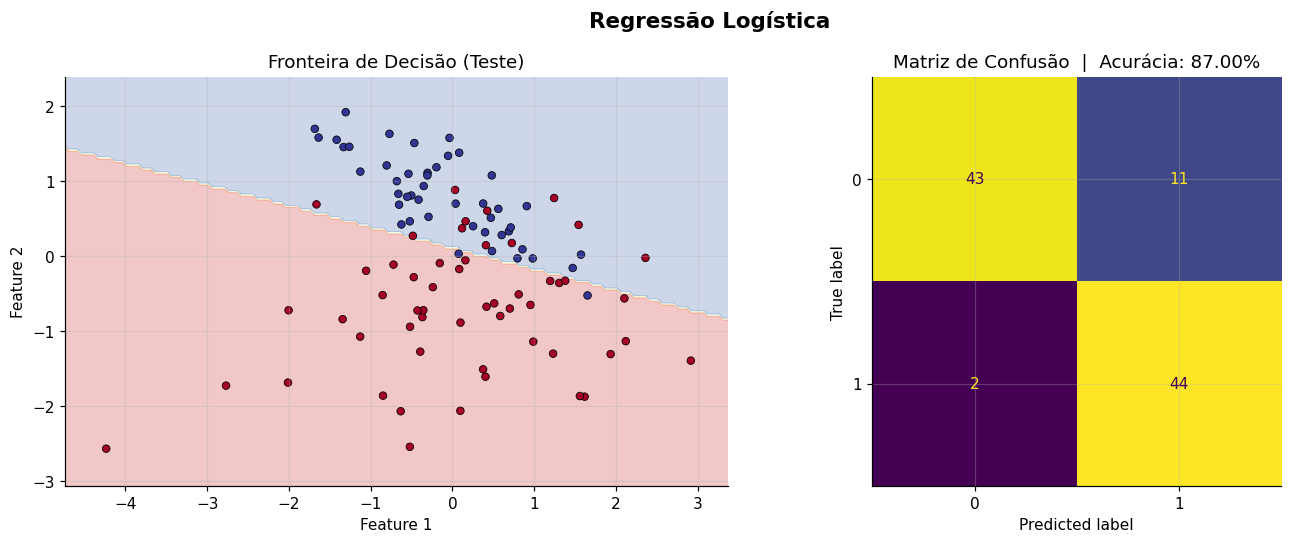

              precision    recall  f1-score   support

           0       0.96      0.80      0.87        54
           1       0.80      0.96      0.87        46

    accuracy                           0.87       100
   macro avg       0.88      0.88      0.87       100
weighted avg       0.88      0.87      0.87       100



In [4]:
# --- Dados aleatórios ---
X_clf, y_clf = make_classification(
    n_samples=400, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, random_state=SEED
)
X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.25, random_state=SEED)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# --- Modelo ---
log_reg = LogisticRegression(random_state=SEED)
log_reg.fit(X_train_s, y_train)
y_pred_lr = log_reg.predict(X_test_s)
acc_lr = accuracy_score(y_test, y_pred_lr)

# --- Fronteira de decisão ---
def plot_decision_boundary(ax, model, X, y, title):
    h = 0.05
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='RdYlBu')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolors='k', s=25, linewidths=0.5)
    ax.set_title(title)
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Regressão Logística', fontsize=14, fontweight='bold')

plot_decision_boundary(axes[0], log_reg, X_test_s, y_test, 'Fronteira de Decisão (Teste)')

cm = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'Matriz de Confusão  |  Acurácia: {acc_lr:.2%}')

plt.tight_layout()
plt.show()
print(classification_report(y_test, y_pred_lr))

### 1.3 Support Vector Machine (SVM)
Encontra o hiperplano de margem máxima que separa as classes.

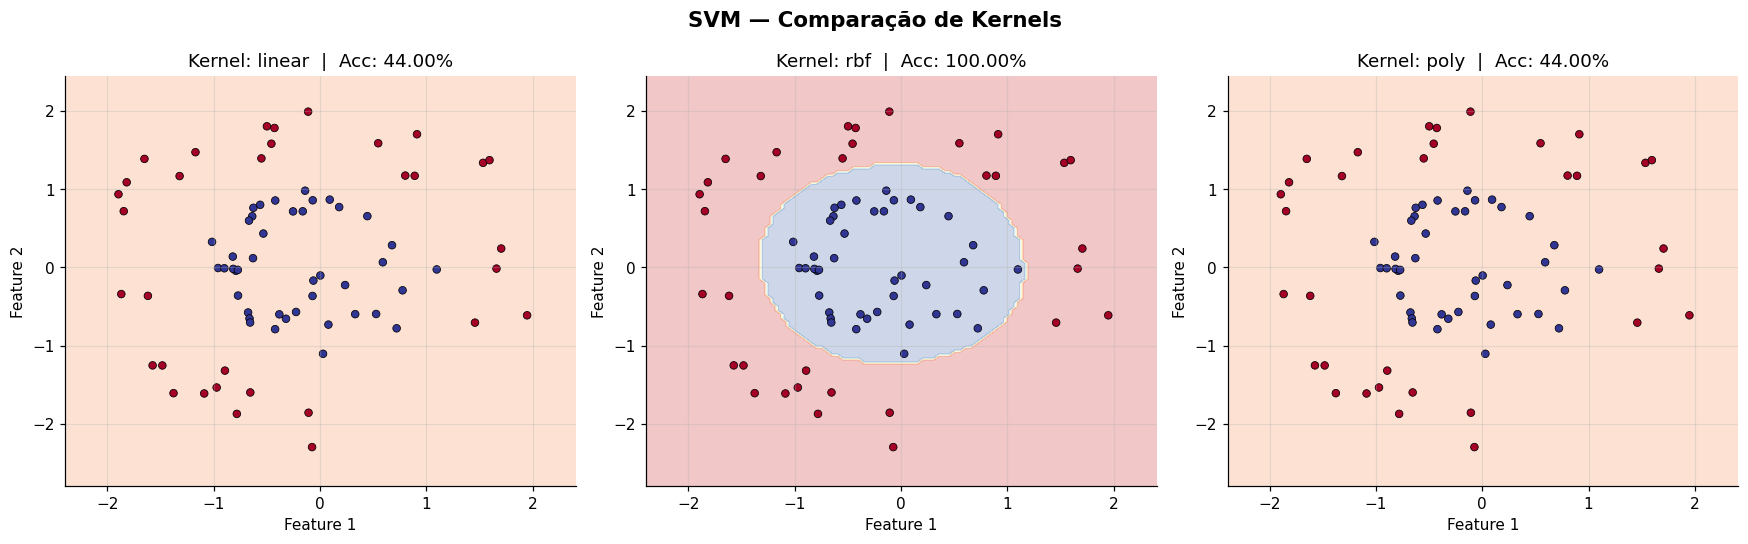

In [5]:
# --- Dados aleatórios (não linearmente separáveis) ---
from sklearn.datasets import make_circles
X_svm, y_svm = make_circles(n_samples=300, noise=0.12, factor=0.4, random_state=SEED)
X_train, X_test, y_train, y_test = train_test_split(X_svm, y_svm, test_size=0.25, random_state=SEED)

scaler_svm = StandardScaler()
X_train_s = scaler_svm.fit_transform(X_train)
X_test_s  = scaler_svm.transform(X_test)

# --- Modelos com diferentes kernels ---
kernels = ['linear', 'rbf', 'poly']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('SVM — Comparação de Kernels', fontsize=14, fontweight='bold')

for ax, kernel in zip(axes, kernels):
    svm = SVC(kernel=kernel, C=1.0, random_state=SEED)
    svm.fit(X_train_s, y_train)
    acc = accuracy_score(y_test, svm.predict(X_test_s))
    plot_decision_boundary(ax, svm, X_test_s, y_test, f'Kernel: {kernel}  |  Acc: {acc:.2%}')

plt.tight_layout()
plt.show()

### 1.4 Árvore de Decisão
Divide os dados recursivamente por regras de if/else aprendidas dos dados.

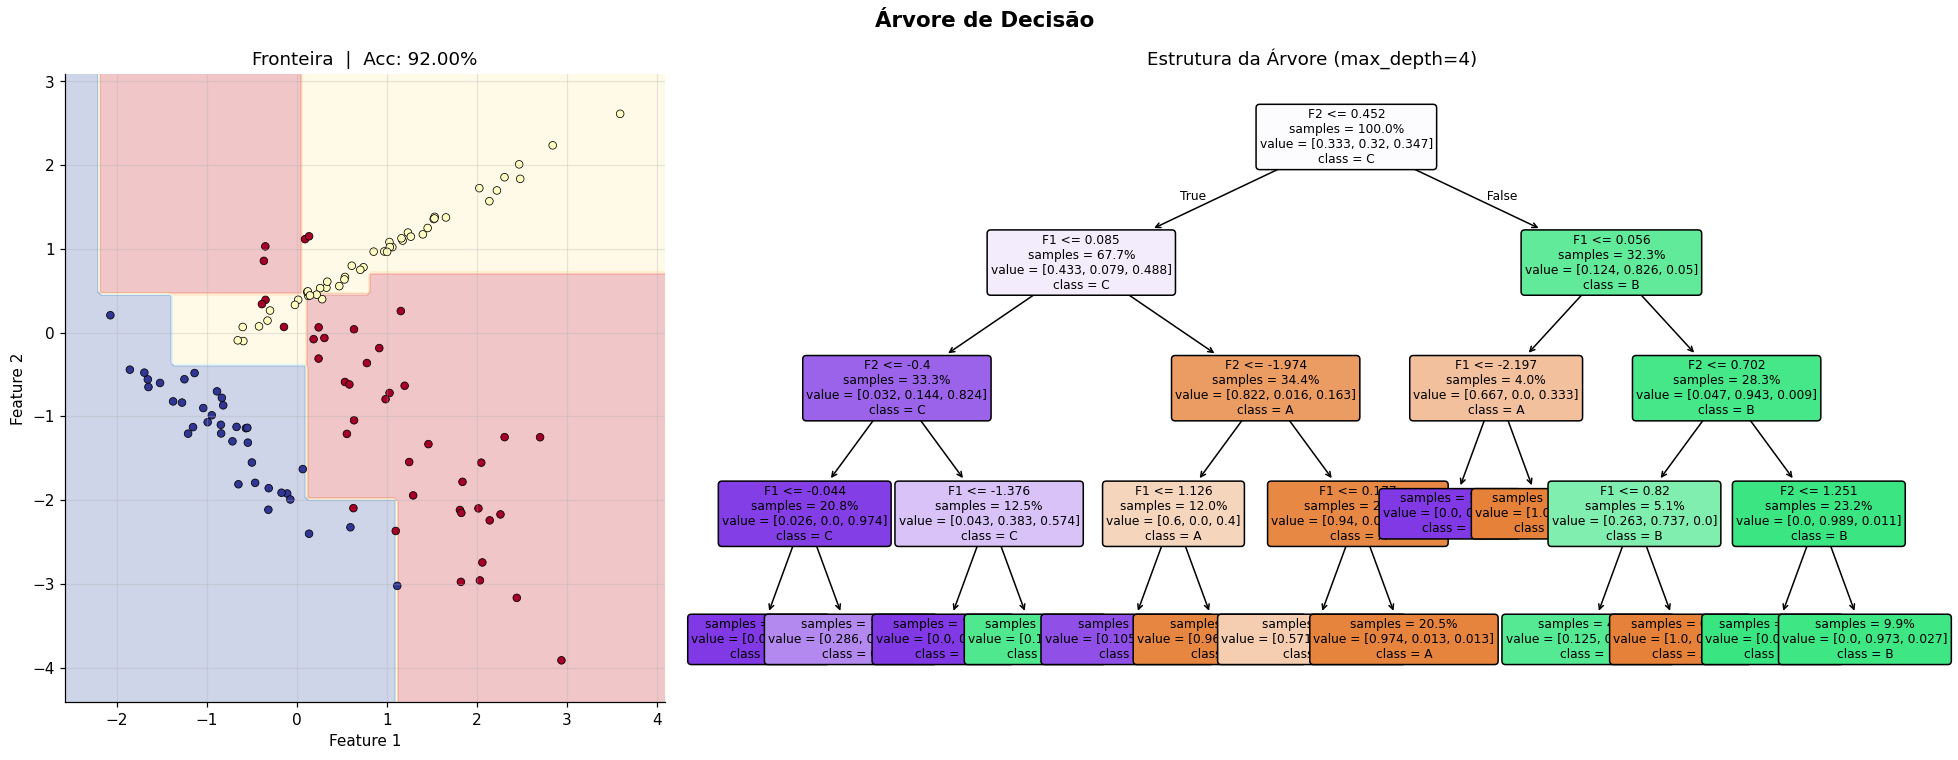

Profundidade real: 4  |  Nós folha: 14


In [6]:
# --- Dados aleatórios multi-classe ---
X_tree, y_tree = make_classification(
    n_samples=500, n_features=2, n_informative=2,
    n_redundant=0, n_classes=3, n_clusters_per_class=1, random_state=SEED
)
X_train, X_test, y_train, y_test = train_test_split(X_tree, y_tree, test_size=0.25, random_state=SEED)

# --- Modelo ---
tree = DecisionTreeClassifier(max_depth=4, random_state=SEED)
tree.fit(X_train, y_train)
acc_tree = accuracy_score(y_test, tree.predict(X_test))

# --- Gráficos ---
fig = plt.figure(figsize=(18, 7))
fig.suptitle('Árvore de Decisão', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 2])

ax_bound = fig.add_subplot(gs[0])
plot_decision_boundary(ax_bound, tree, X_test, y_test, f'Fronteira  |  Acc: {acc_tree:.2%}')

ax_tree = fig.add_subplot(gs[1])
plot_tree(tree, ax=ax_tree, feature_names=['F1', 'F2'],
          class_names=['A', 'B', 'C'], filled=True, rounded=True,
          fontsize=8, impurity=False, proportion=True)
ax_tree.set_title('Estrutura da Árvore (max_depth=4)')

plt.tight_layout()
plt.show()
print(f'Profundidade real: {tree.get_depth()}  |  Nós folha: {tree.get_n_leaves()}')

### 1.5 Random Forest
Ensemble de árvores de decisão treinadas em subconjuntos aleatórios — reduz overfitting.

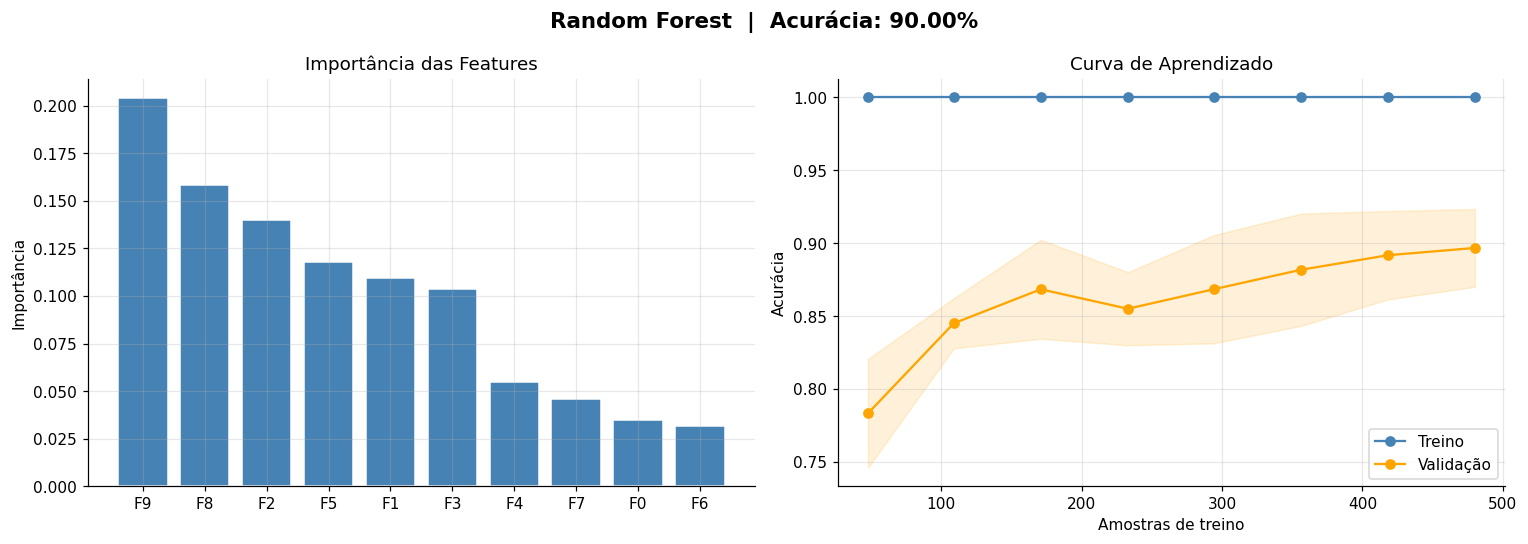

In [7]:
# --- Dados aleatórios ---
X_rf, y_rf = make_classification(
    n_samples=600, n_features=10, n_informative=5,
    n_redundant=2, random_state=SEED
)
X_train, X_test, y_train, y_test = train_test_split(X_rf, y_rf, test_size=0.25, random_state=SEED)

# --- Modelo ---
rf = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf.fit(X_train, y_train)
acc_rf = accuracy_score(y_test, rf.predict(X_test))

# --- Gráficos ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Random Forest  |  Acurácia: {acc_rf:.2%}', fontsize=14, fontweight='bold')

# 1) Importância das features
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
labels  = [f'F{i}' for i in indices]
axes[0].bar(range(len(importances)), importances[indices], color='steelblue', edgecolor='white')
axes[0].set_xticks(range(len(importances)))
axes[0].set_xticklabels(labels)
axes[0].set_title('Importância das Features')
axes[0].set_ylabel('Importância')

# 2) Curva de aprendizado
train_sizes, train_scores, test_scores = learning_curve(
    rf, X_rf, y_rf, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=SEED
)
axes[1].fill_between(train_sizes,
    train_scores.mean(1) - train_scores.std(1),
    train_scores.mean(1) + train_scores.std(1), alpha=0.15, color='steelblue')
axes[1].fill_between(train_sizes,
    test_scores.mean(1) - test_scores.std(1),
    test_scores.mean(1) + test_scores.std(1), alpha=0.15, color='orange')
axes[1].plot(train_sizes, train_scores.mean(1), 'o-', color='steelblue', label='Treino')
axes[1].plot(train_sizes, test_scores.mean(1),  'o-', color='orange',    label='Validação')
axes[1].set_title('Curva de Aprendizado')
axes[1].set_xlabel('Amostras de treino')
axes[1].set_ylabel('Acurácia')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 2. Modelos Não Supervisionados
Trabalham com dados **sem rótulos**, descobrindo estruturas e padrões ocultos.

### 2.1 K-Means Clustering
Agrupa os dados em K clusters minimizando a inércia (distância intra-cluster).

c:\Users\Matheus\miniconda3\envs\PUC\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Matheus\miniconda3\envs\PUC\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Matheus\miniconda3\envs\PUC\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Matheus\miniconda3\envs\PUC\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

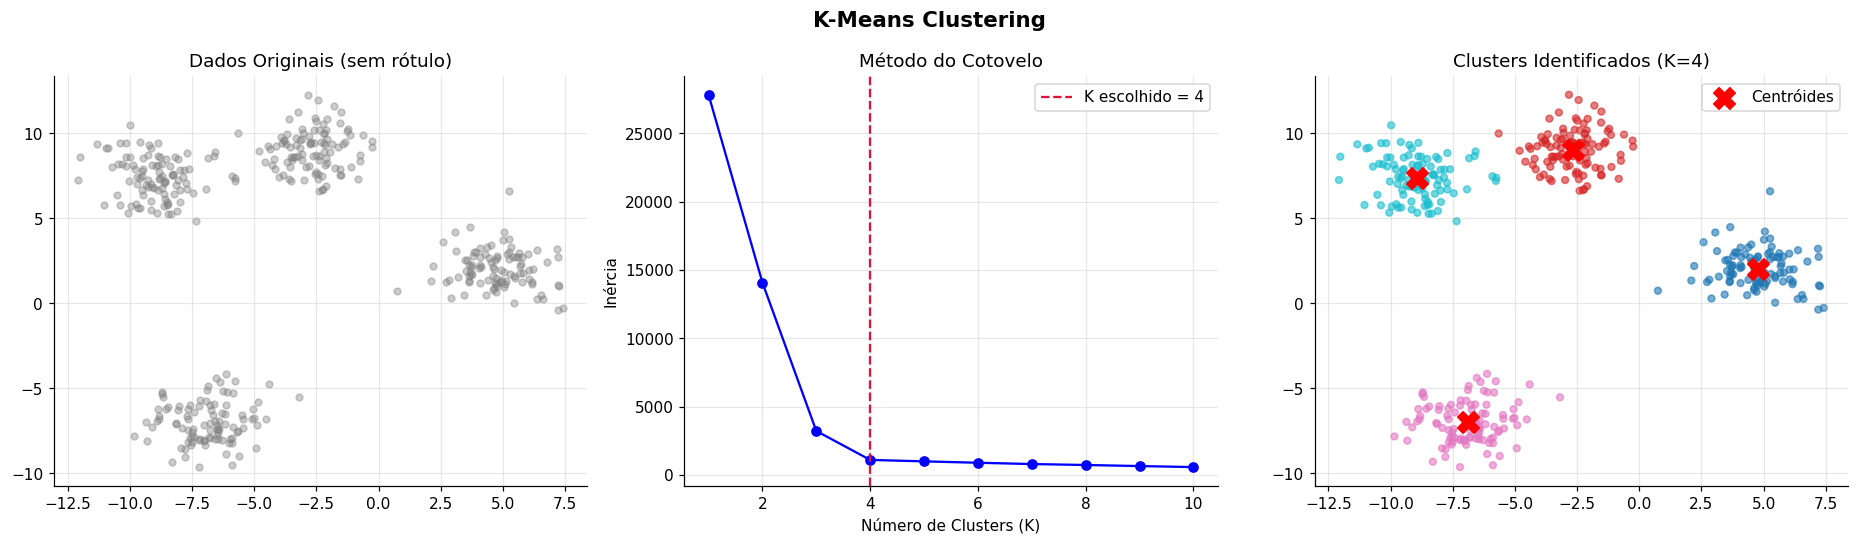

Inércia final: 1103.79


In [8]:
# --- Dados aleatórios ---
X_km, y_km_true = make_blobs(n_samples=400, centers=4, cluster_std=1.2, random_state=SEED)

# --- Método do Cotovelo ---
inertias = []
K_range  = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init='auto')
    km.fit(X_km)
    inertias.append(km.inertia_)

# --- Modelo final ---
km4 = KMeans(n_clusters=4, random_state=SEED, n_init='auto')
labels_km = km4.fit_predict(X_km)
centers   = km4.cluster_centers_

# --- Gráficos ---
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('K-Means Clustering', fontsize=14, fontweight='bold')

# 1) Dados originais
axes[0].scatter(X_km[:, 0], X_km[:, 1], alpha=0.4, s=20, color='gray')
axes[0].set_title('Dados Originais (sem rótulo)')

# 2) Método do cotovelo
axes[1].plot(K_range, inertias, 'bo-', markersize=6)
axes[1].axvline(4, color='crimson', linestyle='--', label='K escolhido = 4')
axes[1].set_title('Método do Cotovelo')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Inércia')
axes[1].legend()

# 3) Clusters identificados
axes[2].scatter(X_km[:, 0], X_km[:, 1], c=labels_km, cmap='tab10', alpha=0.6, s=20)
axes[2].scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, zorder=5, label='Centróides')
axes[2].set_title('Clusters Identificados (K=4)')
axes[2].legend()

plt.tight_layout()
plt.show()
print(f'Inércia final: {km4.inertia_:.2f}')

### 2.2 PCA — Análise de Componentes Principais
Reduz a dimensionalidade preservando a maior variância possível.

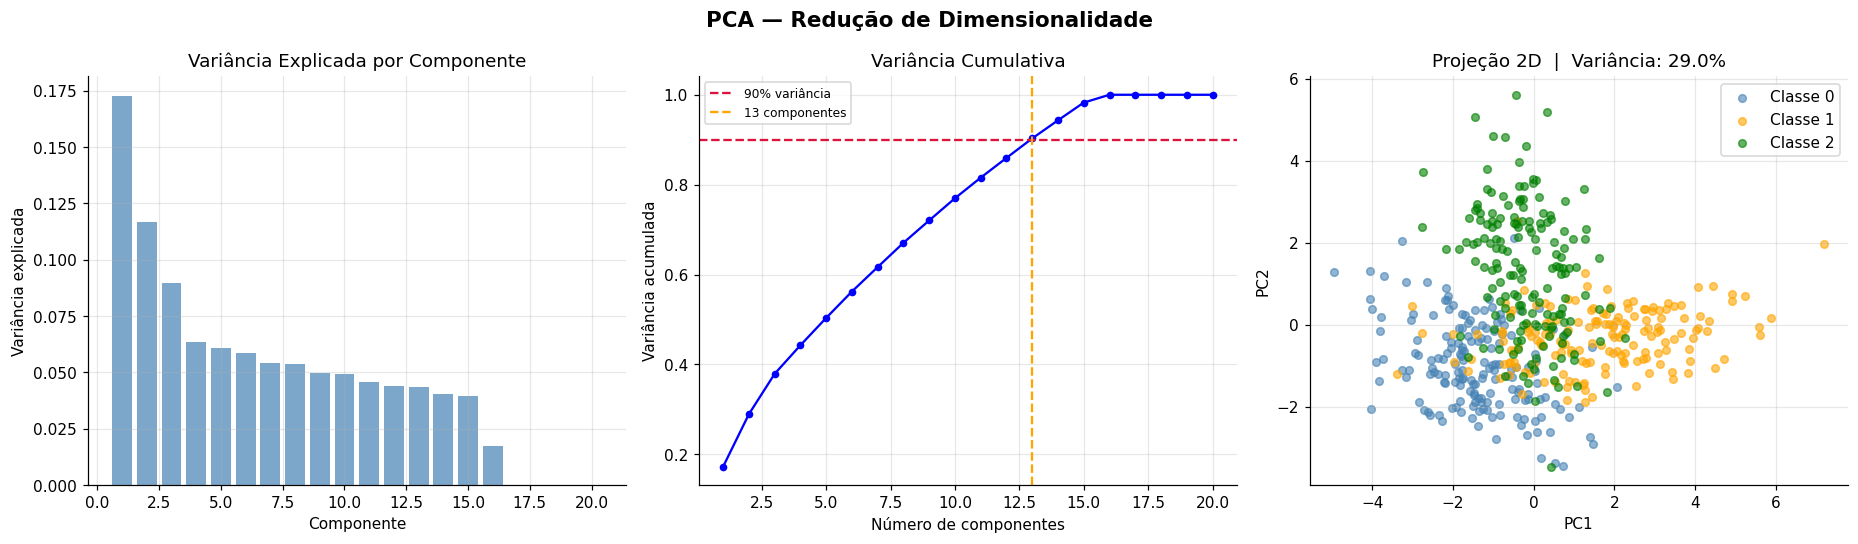

Componentes para 90% da variância: 13


In [9]:
# --- Dados aleatórios de alta dimensão ---
X_pca, y_pca = make_classification(
    n_samples=500, n_features=20, n_informative=6,
    n_redundant=4, n_classes=3, n_clusters_per_class=1, random_state=SEED
)

scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_pca)

# --- PCA completo ---
pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled)
var_cumul = np.cumsum(pca_full.explained_variance_ratio_)

# --- PCA reduzido para 2D ---
pca_2d = PCA(n_components=2, random_state=SEED)
X_2d = pca_2d.fit_transform(X_scaled)

# --- Gráficos ---
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('PCA — Redução de Dimensionalidade', fontsize=14, fontweight='bold')

# 1) Variância por componente
n_comp = len(pca_full.explained_variance_ratio_)
axes[0].bar(range(1, n_comp + 1), pca_full.explained_variance_ratio_, color='steelblue', alpha=0.7)
axes[0].set_title('Variância Explicada por Componente')
axes[0].set_xlabel('Componente'); axes[0].set_ylabel('Variância explicada')

# 2) Variância cumulativa
axes[1].plot(range(1, n_comp + 1), var_cumul, 'bo-', markersize=4)
axes[1].axhline(0.90, color='crimson', linestyle='--', label='90% variância')
n_90 = np.argmax(var_cumul >= 0.90) + 1
axes[1].axvline(n_90, color='orange', linestyle='--', label=f'{n_90} componentes')
axes[1].set_title('Variância Cumulativa')
axes[1].set_xlabel('Número de componentes'); axes[1].set_ylabel('Variância acumulada')
axes[1].legend(fontsize=8)

# 3) Projeção 2D
colors = ['steelblue', 'orange', 'green']
for cls in np.unique(y_pca):
    mask = y_pca == cls
    axes[2].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    label=f'Classe {cls}', alpha=0.6, s=25, color=colors[cls])
axes[2].set_title(f'Projeção 2D  |  Variância: {var_cumul[1]:.1%}')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
axes[2].legend()

plt.tight_layout()
plt.show()
print(f'Componentes para 90% da variância: {n_90}')

### 2.3 DBSCAN — Density-Based Spatial Clustering
Detecta clusters de forma arbitrária e identifica ruído (outliers).

c:\Users\Matheus\miniconda3\envs\PUC\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Matheus\AppData\Local\Temp\ipykernel_42276\3252557110.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_db = plt.cm.get_cmap('tab10', max(1, len(unique_labels) - (1 if -1 in unique_labels else 0)))


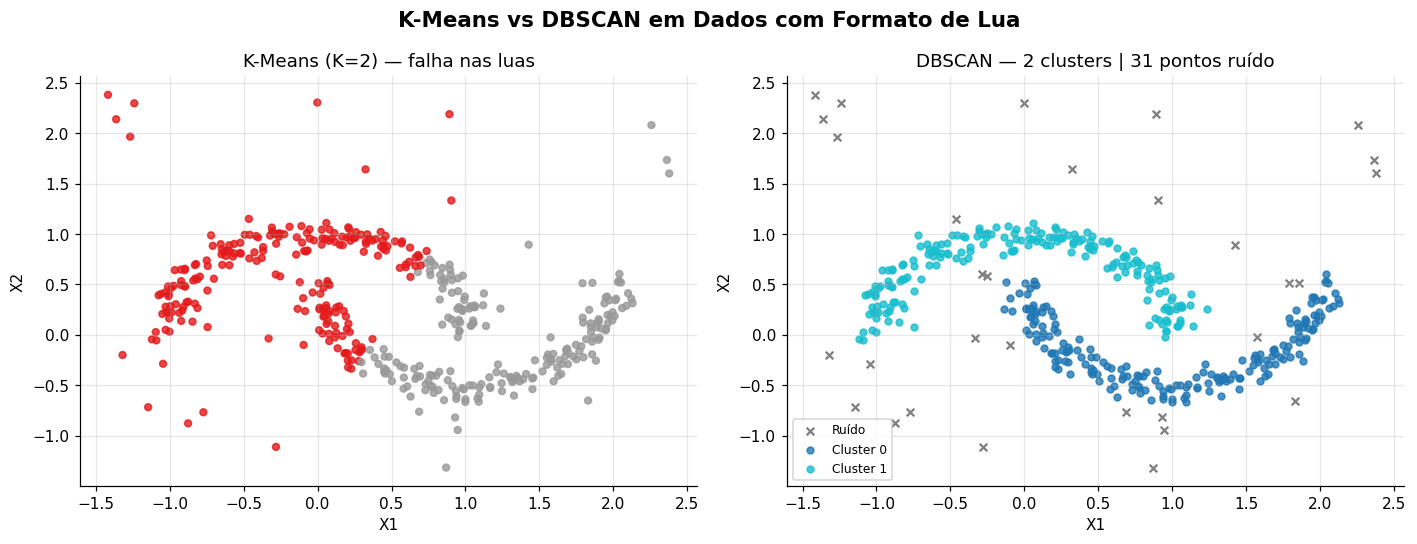

In [10]:
# --- Dados com formas não-convexas ---
from sklearn.datasets import make_moons
X_db, _ = make_moons(n_samples=400, noise=0.08, random_state=SEED)
noise_pts = np.random.uniform(-1.5, 2.5, (30, 2))
X_db = np.vstack([X_db, noise_pts])

# --- Comparação: K-Means vs DBSCAN ---
km_db = KMeans(n_clusters=2, random_state=SEED, n_init='auto')
labels_km_db = km_db.fit_predict(X_db)

db = DBSCAN(eps=0.15, min_samples=5)
labels_db = db.fit_predict(X_db)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('K-Means vs DBSCAN em Dados com Formato de Lua', fontsize=14, fontweight='bold')

axes[0].scatter(X_db[:, 0], X_db[:, 1], c=labels_km_db, cmap='Set1', s=20, alpha=0.8)
axes[0].set_title('K-Means (K=2) — falha nas luas')

unique_labels = set(labels_db)
cmap_db = plt.cm.get_cmap('tab10', max(1, len(unique_labels) - (1 if -1 in unique_labels else 0)))
color_idx = 0
for label in sorted(unique_labels):
    mask = labels_db == label
    if label == -1:
        axes[1].scatter(X_db[mask, 0], X_db[mask, 1], c='gray', s=25, marker='x', label='Ruído')
    else:
        axes[1].scatter(X_db[mask, 0], X_db[mask, 1], s=20, alpha=0.8,
                        color=cmap_db(color_idx), label=f'Cluster {label}')
        color_idx += 1
n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise    = list(labels_db).count(-1)
axes[1].set_title(f'DBSCAN — {n_clusters} clusters | {n_noise} pontos ruído')
axes[1].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel('X1'); ax.set_ylabel('X2')

plt.tight_layout()
plt.show()

---
## 3. Aprendizado Contínuo (Online Learning)
O modelo atualiza seus parâmetros incrementalmente conforme novos dados chegam, sem retreinar do zero.

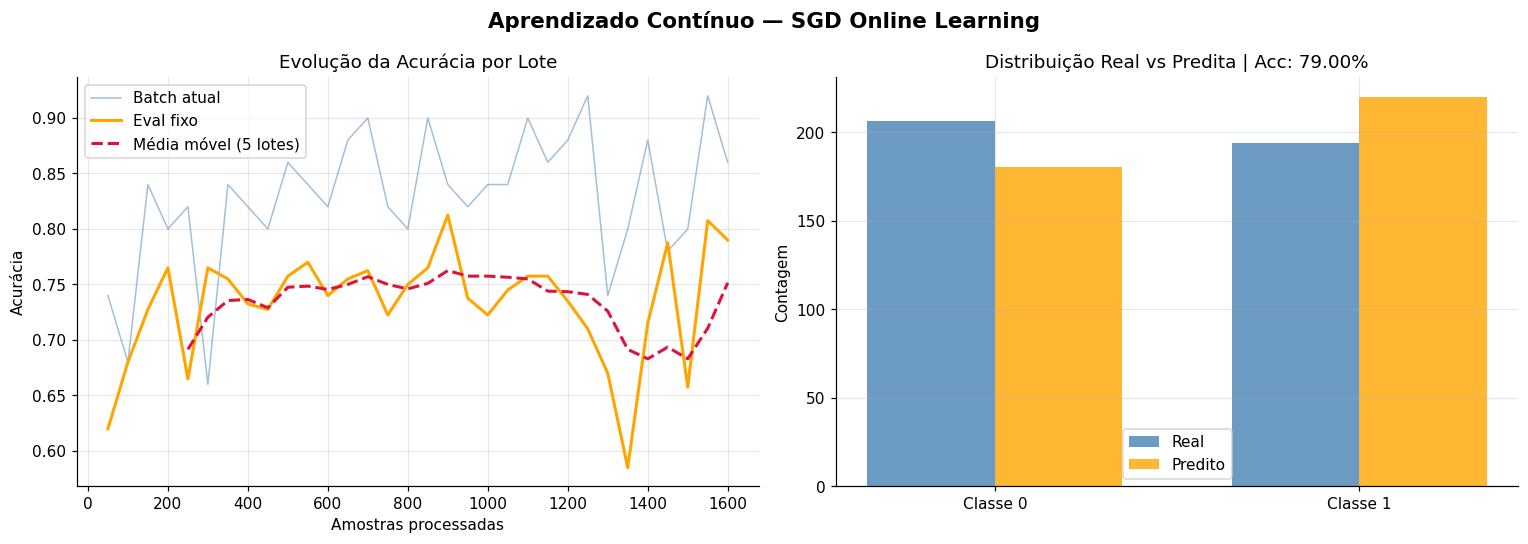

Acurácia final no eval: 79.00%
Lotes processados      : 32
Amostras no stream     : 1600


In [11]:
# --- Dados simulando fluxo contínuo ---
np.random.seed(SEED)
N_TOTAL = 2000
X_online, y_online = make_classification(
    n_samples=N_TOTAL, n_features=15, n_informative=7,
    n_redundant=3, random_state=SEED
)

scaler_ol = StandardScaler()
X_online  = scaler_ol.fit_transform(X_online)

# --- Aprendizado em mini-lotes ---
sgd = SGDClassifier(loss='log_loss', random_state=SEED)

batch_size = 50
acc_train  = []
acc_batch  = []
batch_nums = []

X_eval, y_eval   = X_online[-400:], y_online[-400:]
X_stream, y_stream = X_online[:-400], y_online[:-400]

for i, start in enumerate(range(0, len(X_stream), batch_size)):
    X_b = X_stream[start:start + batch_size]
    y_b = y_stream[start:start + batch_size]
    sgd.partial_fit(X_b, y_b, classes=np.unique(y_online))
    acc_batch.append(accuracy_score(y_b, sgd.predict(X_b)))
    acc_train.append(accuracy_score(y_eval, sgd.predict(X_eval)))
    batch_nums.append((i + 1) * batch_size)

# --- Gráficos ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Aprendizado Contínuo — SGD Online Learning', fontsize=14, fontweight='bold')

# 1) Acurácia ao longo do tempo
axes[0].plot(batch_nums, acc_batch, alpha=0.5, lw=1, color='steelblue', label='Batch atual')
axes[0].plot(batch_nums, acc_train, lw=2,   color='orange',    label='Eval fixo')
window = 5
moving_avg = np.convolve(acc_train, np.ones(window)/window, mode='valid')
axes[0].plot(batch_nums[window-1:], moving_avg, lw=2, color='crimson',
             linestyle='--', label=f'Média móvel ({window} lotes)')
axes[0].set_title('Evolução da Acurácia por Lote')
axes[0].set_xlabel('Amostras processadas')
axes[0].set_ylabel('Acurácia')
axes[0].legend()

# 2) Distribuição Real vs Predita
y_final_pred = sgd.predict(X_eval)
labels_pred, counts_pred = np.unique(y_final_pred, return_counts=True)
labels_true, counts_true = np.unique(y_eval,        return_counts=True)

x_pos = np.arange(len(labels_pred))
width = 0.35
axes[1].bar(x_pos - width/2, counts_true, width, label='Real',   color='steelblue', alpha=0.8)
axes[1].bar(x_pos + width/2, counts_pred, width, label='Predito',color='orange',    alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'Classe {l}' for l in labels_pred])
axes[1].set_title(f'Distribuição Real vs Predita | Acc: {acc_train[-1]:.2%}')
axes[1].set_ylabel('Contagem')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Acurácia final no eval: {acc_train[-1]:.2%}')
print(f'Lotes processados      : {len(batch_nums)}')
print(f'Amostras no stream     : {len(X_stream)}')

---
## 4. Comparativo Final — Classificadores

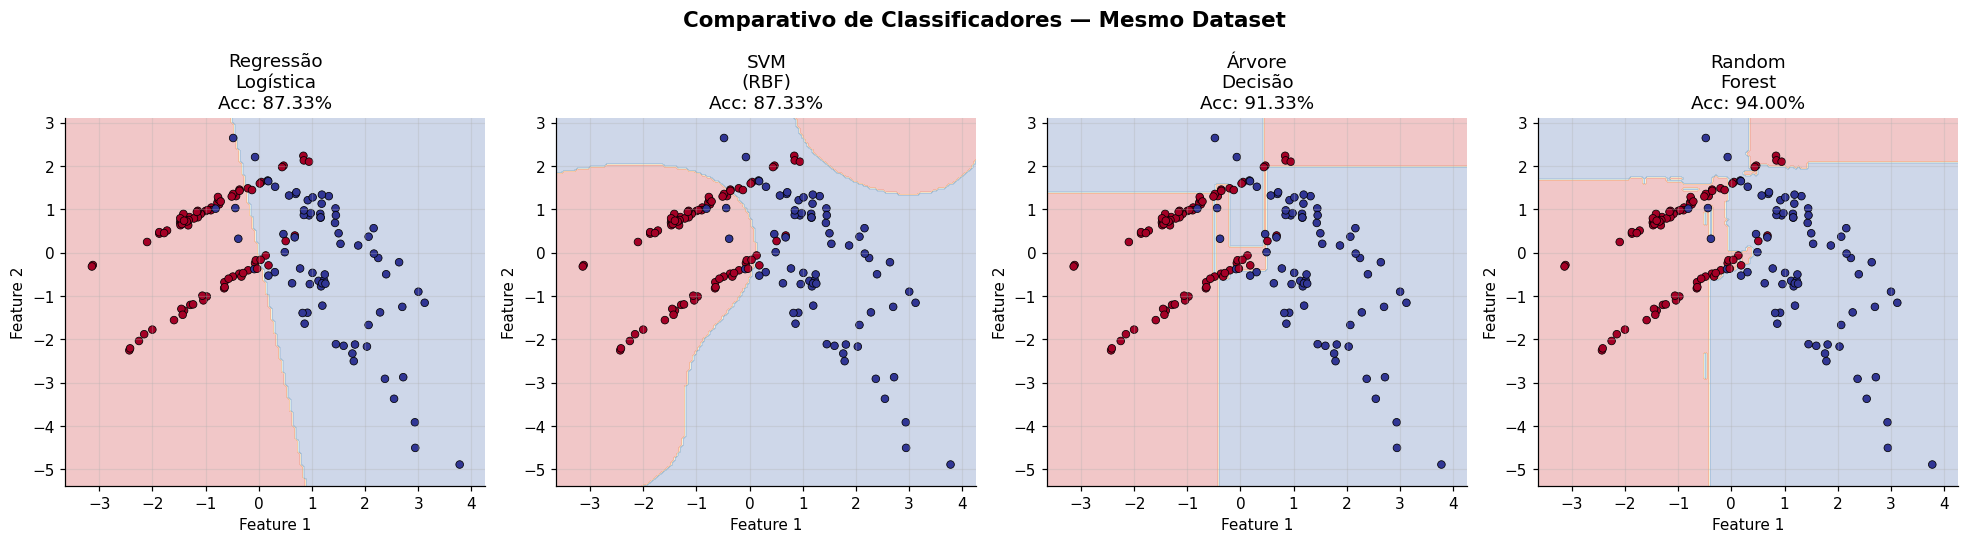

In [12]:
# --- Mesmo dataset para todos os classificadores ---
X_c, y_c = make_classification(
    n_samples=500, n_features=2, n_informative=2,
    n_redundant=0, random_state=SEED
)
X_tr, X_te, y_tr, y_te = train_test_split(X_c, y_c, test_size=0.3, random_state=SEED)

classifiers = {
    'Regressão\nLogística': LogisticRegression(random_state=SEED),
    'SVM\n(RBF)':           SVC(kernel='rbf', C=1, random_state=SEED),
    'Árvore\nDecisão':      DecisionTreeClassifier(max_depth=5, random_state=SEED),
    'Random\nForest':       RandomForestClassifier(n_estimators=100, random_state=SEED),
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Comparativo de Classificadores — Mesmo Dataset', fontsize=14, fontweight='bold')

for ax, (name, clf) in zip(axes, classifiers.items()):
    clf.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, clf.predict(X_te))
    plot_decision_boundary(ax, clf, X_te, y_te, f'{name}\nAcc: {acc:.2%}')

plt.tight_layout()
plt.show()

---
## Conclusão

| Paradigma | Modelo | Quando usar |
|---|---|---|
| **Supervisionado** | Regressão Linear | Prever valores contínuos com relação linear |
| **Supervisionado** | Regressão Logística | Classificação binária simples, interpretável |
| **Supervisionado** | SVM | Alta dimensão, dados não lineares (kernel trick) |
| **Supervisionado** | Árvore de Decisão | Interpretabilidade, dados categóricos |
| **Supervisionado** | Random Forest | Alta acurácia, resistente a overfitting |
| **Não Supervisionado** | K-Means | Clusters esféricos, K conhecido |
| **Não Supervisionado** | PCA | Redução de dimensão, visualização |
| **Não Supervisionado** | DBSCAN | Clusters arbitrários, detecção de outliers |
| **Online Learning** | SGD | Dados em fluxo, memória limitada |